
EXAMPLE 1: Using convenience function
Predictor Matrix Optimization
Features: 12
Method: greedy
Starting optimization...

Optimization Complete!
Features ordered: 12
Avg predictors: 3.42
Max predictors: 9
Monotonicity: 100.0%
Smoothness: 0.57
Runtime: 0.000s

Optimal ordering: ['10', '6', '1', '8', '7', '9', '0', '3', '5', '4', '11', '2']
Predictor counts: [0 0 1 1 2 3 3 4 5 6 7 9]

EXAMPLE 2: Using optimizer class

Predictor matrix shape: (12, 12)
Total predictors: 41

Predictor Matrix (lower triangle):
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 0 0 0 0 0 0 0]
 [1 0 1 0 1 0 0 0 0 0 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0]
 [1 1 1 0 1 1 0 0 0 0 0 0]
 [1 1 1 0 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 0 0 1 0 0 0]
 [1 1 1 0 1 1 0 1 1 1 1 0]]

EXAMPLE 3: Visualization
Figure saved to: predictor_optimization.png


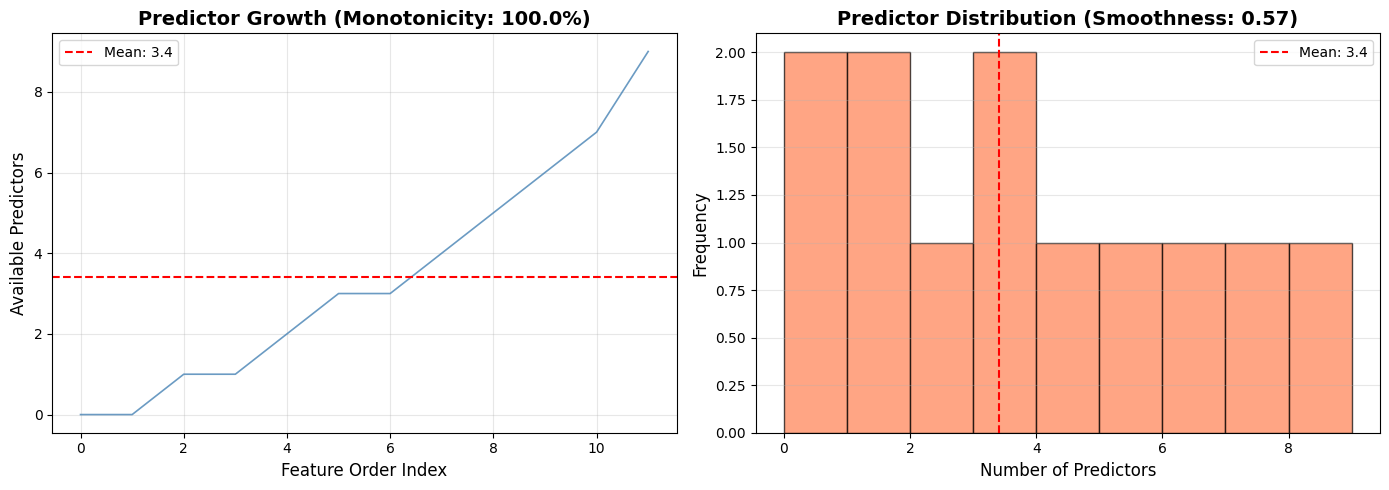


EXAMPLE 4: Comparison of methods

--- Method: GREEDY ---
Monotonicity: 100.0%
Avg predictors: 3.42
Smoothness: 0.57

--- Method: DEGREE ---
Monotonicity: 90.9%
Avg predictors: 3.42
Smoothness: 1.27


In [11]:
"""
Predictor Matrix Optimization for Synthpop Synthetic Data Generation.

This module provides algorithms to determine optimal feature ordering for building
predictor matrices in Synthpop, ensuring monotonically increasing predictor counts
across the synthesis sequence.

Author: trinhthechuong
Date: 2025-10-01
"""

import numpy as np
import heapq
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Union, Optional
import time
import matplotlib.pyplot as plt


class PredictorMatrixOptimizer:
    """
    Optimizer for determining optimal feature ordering in Synthpop predictor matrices.
    
    This class implements multiple algorithms (greedy, degree-based) to find an optimal
    ordering of features such that the predictor matrix (lower triangular) exhibits
    monotonically increasing predictor counts per feature.
    
    Attributes:
        corr_dict (dict): Correlation dictionary mapping feature IDs to correlated features.
        method (str): Optimization method ('greedy' or 'degree').
        ordered_features (list): Computed optimal feature ordering.
        predictor_counts (np.ndarray): Number of available predictors per feature.
        
    Example:
        >>> corr_dict = {'0': [1, 3, 4], '1': [0, 2], '2': [1]}
        >>> optimizer = PredictorMatrixOptimizer(corr_dict, method='greedy')
        >>> ordered, counts = optimizer.optimize()
        >>> print(f"Optimal order: {ordered}")
        >>> print(f"Predictor counts: {counts}")
    """
    
    def __init__(self, 
                 corr_dict: Dict[Union[str, int], List[Union[str, int]]], 
                 method: str = 'greedy'):
        """
        Initialize the PredictorMatrixOptimizer.
        
        Args:
            corr_dict (dict): Correlation dictionary where keys are feature identifiers 
                and values are lists of correlated feature identifiers.
                Example: {'0': [1, 3, 4], '1': [0, 2, 3]}
            method (str): Optimization method. Options: 'greedy', 'degree'.
                Default: 'greedy' (recommended for optimal results).
        
        Raises:
            ValueError: If corr_dict is empty or method is invalid.
            TypeError: If corr_dict is not a dictionary or contains invalid types.
        """
        if not isinstance(corr_dict, dict):
            raise TypeError(f"corr_dict must be a dictionary, got {type(corr_dict)}")
        
        if not corr_dict:
            raise ValueError("corr_dict cannot be empty")
        
        if method not in ['greedy', 'degree']:
            raise ValueError(f"Invalid method '{method}'. Choose 'greedy' or 'degree'")
        
        self.corr_dict = corr_dict
        self.method = method
        self.ordered_features = None
        self.predictor_counts = None
        self._normalized_dict = None
        
    def _normalize_correlation_dict(self) -> Dict[str, Set[str]]:
        """
        Normalize correlation dictionary by ensuring all features are included and converting to sets.
        
        This method:
        1. Collects all unique features from keys and values
        2. Ensures bidirectional relationships are captured
        3. Converts lists to sets for O(1) lookup operations
        
        Returns:
            dict: Normalized correlation dictionary with string keys and set values.
                Example: {'0': {'1', '3'}, '1': {'0', '2'}, '2': {'1'}}
        
        Raises:
            ValueError: If any feature ID cannot be converted to string.
        """
        # Collect all unique features
        all_features = set()
        
        try:
            for key, values in self.corr_dict.items():
                all_features.add(str(key))
                for val in values:
                    all_features.add(str(val))
        except (TypeError, ValueError) as e:
            raise ValueError(f"Invalid feature ID format: {e}")
        
        # Build normalized dictionary with sets
        normalized = {}
        for feat in all_features:
            if feat in self.corr_dict:
                # Convert list to set of strings
                normalized[feat] = {str(v) for v in self.corr_dict[feat]}
            else:
                # Feature appeared only as a value, not as a key
                normalized[feat] = set()
        
        return normalized
    
    def _greedy_ordering(self) -> Tuple[List[str], np.ndarray]:
        """
        Compute optimal feature ordering using greedy algorithm.
        
        Algorithm:
            At each step, select the feature with the minimum number of available
            predictors from the already-synthesized features. This ensures a smooth,
            monotonically increasing predictor count distribution.
        
        Strategy:
            1. Maintain 'synthesized' set: features already ordered
            2. For each remaining feature, count correlations with synthesized features
            3. Select feature with minimum count (tiebreaker: higher total correlations)
            4. Add selected feature to ordering and update synthesized set
        
        Time Complexity:
            O(n² * log(n)) where n is the number of features.
            - Outer loop: n iterations
            - Inner loop: n candidates with heap operations (log n)
        
        Space Complexity:
            O(n) for storing sets and intermediate results.
        
        Returns:
            tuple: (ordered_features, predictor_counts)
                - ordered_features (list): Optimal feature ordering as strings
                - predictor_counts (np.ndarray): Number of available predictors per step
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer({'0': [1, 2], '1': [0], '2': [0]})
            >>> ordered, counts = optimizer._greedy_ordering()
            >>> print(ordered)  # ['0', '1', '2'] or ['0', '2', '1']
            >>> print(counts)   # [0, 1, 1]
        """
        corr_dict = self._normalized_dict
        remaining = set(corr_dict.keys())
        ordered = []
        synthesized = set()
        predictor_counts = []
        
        while remaining:
            candidates = []
            
            for feat in remaining:
                # Count available predictors from synthesized features
                available_predictors = len(corr_dict[feat] & synthesized)
                
                # Total correlations (for tiebreaker - prefer high connectivity)
                total_correlations = len(corr_dict[feat])
                
                # Heap: (available_predictors, -total_correlations, feat)
                # Minimize available_predictors, then maximize total_correlations
                heapq.heappush(candidates, 
                              (available_predictors, -total_correlations, feat))
            
            # Select feature with minimum available predictors
            avail_pred, _, selected = heapq.heappop(candidates)
            
            ordered.append(selected)
            predictor_counts.append(avail_pred)
            synthesized.add(selected)
            remaining.remove(selected)
        
        return ordered, np.array(predictor_counts, dtype=np.int32)
    
    def _degree_based_ordering(self) -> Tuple[List[str], np.ndarray]:
        """
        Compute feature ordering based on correlation degree (ascending).
        
        Algorithm:
            Sort features by the number of correlations (degree) in ascending order.
            Features with fewer correlations are considered more "independent" and
            are placed first in the synthesis sequence.
        
        Strategy:
            1. Calculate degree (correlation count) for each feature
            2. Sort features by degree (ascending)
            3. Compute actual available predictors at each step
        
        Time Complexity:
            O(n * log(n)) for sorting + O(n * m) for predictor calculation
            where n is features and m is average correlations.
        
        Space Complexity:
            O(n) for storing ordering and counts.
        
        Returns:
            tuple: (ordered_features, predictor_counts)
                - ordered_features (list): Degree-based feature ordering
                - predictor_counts (np.ndarray): Number of available predictors per step
        
        Note:
            This method is faster than greedy but may not achieve optimal monotonicity,
            especially for clustered correlation structures.
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer({'0': [1, 2, 3], '1': [0], '2': [0]})
            >>> ordered, counts = optimizer._degree_based_ordering()
            >>> print(ordered)  # ['1', '2', '0'] (ascending degree: 1, 1, 3)
        """
        corr_dict = self._normalized_dict
        synthesized = set()
        predictor_counts = []
        
        # Sort by degree (number of correlations)
        ordered = sorted(corr_dict.keys(), key=lambda x: len(corr_dict[x]))
        
        # Calculate actual available predictors at each step
        for feat in ordered:
            available_predictors = len(corr_dict[feat] & synthesized)
            predictor_counts.append(available_predictors)
            synthesized.add(feat)
        
        return ordered, np.array(predictor_counts, dtype=np.int32)
    
    def optimize(self) -> Tuple[List[str], np.ndarray]:
        """
        Execute optimization to determine optimal feature ordering.
        
        This method normalizes the correlation dictionary and applies the selected
        optimization algorithm to compute the feature ordering.
        
        Returns:
            tuple: (ordered_features, predictor_counts)
                - ordered_features (list): Optimal feature ordering
                - predictor_counts (np.ndarray): Number of available predictors per feature
        
        Raises:
            RuntimeError: If optimization fails due to internal errors.
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer(corr_dict, method='greedy')
            >>> ordered, counts = optimizer.optimize()
            >>> print(f"Monotonicity: {np.all(np.diff(counts) >= 0)}")
        """
        # Normalize correlation dictionary
        self._normalized_dict = self._normalize_correlation_dict()
        
        # Apply selected algorithm
        if self.method == 'greedy':
            self.ordered_features, self.predictor_counts = self._greedy_ordering()
        elif self.method == 'degree':
            self.ordered_features, self.predictor_counts = self._degree_based_ordering()
        else:
            raise RuntimeError(f"Unknown method: {self.method}")
        
        return self.ordered_features, self.predictor_counts
    
    def build_predictor_matrix(self, sparse: bool = False) -> Union[np.ndarray, 'scipy.sparse.csr_matrix']:
        """
        Build predictor matrix based on optimized feature ordering.
        
        The predictor matrix is a lower triangular binary matrix where:
        - matrix[i, j] = 1: feature j is used as predictor for feature i (j < i)
        - matrix[i, j] = 0: otherwise
        
        Args:
            sparse (bool): If True, return scipy sparse CSR matrix (memory efficient).
                Recommended for large feature sets (>10k features).
                Default: False (returns dense numpy array).
        
        Returns:
            np.ndarray or scipy.sparse.csr_matrix: Predictor matrix of shape (n, n)
                where n is the number of features.
        
        Raises:
            RuntimeError: If optimize() has not been called yet.
            ImportError: If sparse=True but scipy is not installed.
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer(corr_dict)
            >>> optimizer.optimize()
            >>> matrix = optimizer.build_predictor_matrix(sparse=False)
            >>> print(f"Matrix shape: {matrix.shape}")
            >>> print(f"Total predictors: {matrix.sum()}")
        """
        if self.ordered_features is None:
            raise RuntimeError("Must call optimize() before building matrix")
        
        if sparse:
            try:
                from scipy.sparse import lil_matrix
            except ImportError:
                raise ImportError("scipy is required for sparse matrices. Install: pip install scipy")
            
            return self._build_sparse_matrix()
        else:
            return self._build_dense_matrix()
    
    def _build_dense_matrix(self) -> np.ndarray:
        """
        Build dense numpy predictor matrix.
        
        Returns:
            np.ndarray: Dense binary matrix of shape (n, n) with dtype int8.
        
        Memory:
            For n features: n * n * 1 byte (int8)
            Example: 12 features → 144 bytes, 41000 features → 1.6 GB
        """
        n = len(self.ordered_features)
        matrix = np.zeros((n, n), dtype=np.int8)
        
        # Create feature index mapping
        feat_to_idx = {feat: idx for idx, feat in enumerate(self.ordered_features)}
        
        # Fill lower triangle
        for i, feat in enumerate(self.ordered_features):
            if feat in self._normalized_dict:
                for predictor_feat in self._normalized_dict[feat]:
                    if predictor_feat in feat_to_idx:
                        j = feat_to_idx[predictor_feat]
                        if j < i:  # Lower triangle only
                            matrix[i, j] = 1
        
        return matrix
    
    def _build_sparse_matrix(self):
        """
        Build sparse scipy predictor matrix in CSR format.
        
        Returns:
            scipy.sparse.csr_matrix: Sparse binary matrix in CSR format.
        
        Memory:
            Approximately: non_zeros * 12 bytes
            Example: 41000 features, 1% density → ~200 MB
        """
        from scipy.sparse import lil_matrix
        
        n = len(self.ordered_features)
        matrix = lil_matrix((n, n), dtype=np.int8)
        
        feat_to_idx = {feat: idx for idx, feat in enumerate(self.ordered_features)}
        
        for i, feat in enumerate(self.ordered_features):
            if feat in self._normalized_dict:
                for predictor_feat in self._normalized_dict[feat]:
                    if predictor_feat in feat_to_idx:
                        j = feat_to_idx[predictor_feat]
                        if j < i:
                            matrix[i, j] = 1
        
        return matrix.tocsr()
    
    def get_metrics(self) -> Dict[str, float]:
        """
        Calculate optimization quality metrics.
        
        Metrics computed:
        - monotonic_ratio: Proportion of non-decreasing steps in predictor counts
        - smoothness: Standard deviation of first differences (lower is better)
        - avg_predictors: Mean number of predictors per feature
        - max_predictors: Maximum number of predictors for any feature
        - min_predictors: Minimum number of predictors (usually 0)
        
        Returns:
            dict: Dictionary containing quality metrics with float values.
        
        Raises:
            RuntimeError: If optimize() has not been called yet.
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer(corr_dict)
            >>> optimizer.optimize()
            >>> metrics = optimizer.get_metrics()
            >>> print(f"Monotonicity: {metrics['monotonic_ratio']:.2%}")
            >>> print(f"Avg predictors: {metrics['avg_predictors']:.2f}")
        """
        if self.predictor_counts is None:
            raise RuntimeError("Must call optimize() before getting metrics")
        
        diffs = np.diff(self.predictor_counts)
        
        metrics = {
            'monotonic_ratio': float(np.sum(diffs >= 0) / len(diffs)) if len(diffs) > 0 else 1.0,
            'smoothness': float(np.std(diffs)) if len(diffs) > 0 else 0.0,
            'avg_predictors': float(self.predictor_counts.mean()),
            'max_predictors': int(self.predictor_counts.max()),
            'min_predictors': int(self.predictor_counts.min()),
            'n_features': len(self.ordered_features)
        }
        
        return metrics
    
    def visualize(self, save_path: Optional[str] = None) -> Dict[str, float]:
        """
        Visualize predictor count distribution and optimization quality.
        
        Creates a two-panel figure:
        1. Line plot: Predictor count growth across feature ordering
        2. Histogram: Distribution of predictor counts
        
        Args:
            save_path (str, optional): Path to save the figure (PNG, PDF, etc.).
                If None, displays the plot interactively.
                Example: 'predictor_analysis.png'
        
        Returns:
            dict: Quality metrics (same as get_metrics()).
        
        Raises:
            RuntimeError: If optimize() has not been called yet.
            ImportError: If matplotlib is not installed.
        
        Example:
            >>> optimizer = PredictorMatrixOptimizer(corr_dict)
            >>> optimizer.optimize()
            >>> metrics = optimizer.visualize(save_path='results.png')
        """
        if self.predictor_counts is None:
            raise RuntimeError("Must call optimize() before visualization")
        
        metrics = self.get_metrics()
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Line plot: Predictor growth
        axes[0].plot(self.predictor_counts, linewidth=1.2, alpha=0.8, color='steelblue')
        axes[0].set_xlabel('Feature Order Index', fontsize=12)
        axes[0].set_ylabel('Available Predictors', fontsize=12)
        axes[0].set_title(f'Predictor Growth (Monotonicity: {metrics["monotonic_ratio"]:.1%})', 
                          fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].axhline(metrics['avg_predictors'], color='red', linestyle='--', 
                        linewidth=1.5, label=f'Mean: {metrics["avg_predictors"]:.1f}')
        axes[0].legend(fontsize=10)
        
        # Histogram: Distribution
        n_bins = min(50, len(np.unique(self.predictor_counts)))
        axes[1].hist(self.predictor_counts, bins=n_bins, 
                     edgecolor='black', alpha=0.7, color='coral')
        axes[1].set_xlabel('Number of Predictors', fontsize=12)
        axes[1].set_ylabel('Frequency', fontsize=12)
        axes[1].set_title(f'Predictor Distribution (Smoothness: {metrics["smoothness"]:.2f})', 
                          fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].axvline(metrics['avg_predictors'], color='red', linestyle='--', 
                        linewidth=1.5, label=f'Mean: {metrics["avg_predictors"]:.1f}')
        axes[1].legend(fontsize=10)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
        
        return metrics


def optimize_predictor_order(corr_dict: Dict[Union[str, int], List[Union[str, int]]], 
                              method: str = 'greedy',
                              verbose: bool = True) -> Tuple[List[str], np.ndarray, Dict[str, float]]:
    """
    Convenience function to optimize feature ordering for Synthpop predictor matrix.
    
    This function provides a simple interface to the PredictorMatrixOptimizer class,
    suitable for quick optimization without object instantiation.
    
    Args:
        corr_dict (dict): Correlation dictionary mapping feature IDs to lists of 
            correlated feature IDs.
            Example: {'0': [1, 3, 4], '1': [0, 2, 3], '2': [1]}
        method (str): Optimization method. Options: 'greedy' (recommended), 'degree'.
            Default: 'greedy'.
        verbose (bool): If True, print optimization progress and metrics.
            Default: True.
    
    Returns:
        tuple: (ordered_features, predictor_counts, metrics)
            - ordered_features (list): Optimal feature ordering
            - predictor_counts (np.ndarray): Number of available predictors per feature
            - metrics (dict): Quality metrics including monotonic_ratio, smoothness, etc.
    
    Raises:
        ValueError: If corr_dict is empty or method is invalid.
        TypeError: If corr_dict has invalid format.
    
    Example:
        >>> corr_dict = {'0': [1, 3], '1': [0, 2], '2': [1], '3': [0]}
        >>> ordered, counts, metrics = optimize_predictor_order(corr_dict)
        >>> print(f"Optimal order: {ordered}")
        >>> print(f"Monotonicity: {metrics['monotonic_ratio']:.2%}")
    """
    start_time = time.time()
    
    if verbose:
        print(f"{'='*60}")
        print(f"Predictor Matrix Optimization")
        print(f"{'='*60}")
        print(f"Features: {len(corr_dict)}")
        print(f"Method: {method}")
        print(f"Starting optimization...")
    
    # Initialize optimizer
    optimizer = PredictorMatrixOptimizer(corr_dict, method=method)
    
    # Run optimization
    ordered_features, predictor_counts = optimizer.optimize()
    
    # Get metrics
    metrics = optimizer.get_metrics()
    metrics['runtime_seconds'] = time.time() - start_time
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Optimization Complete!")
        print(f"{'='*60}")
        print(f"Features ordered: {metrics['n_features']}")
        print(f"Avg predictors: {metrics['avg_predictors']:.2f}")
        print(f"Max predictors: {metrics['max_predictors']}")
        print(f"Monotonicity: {metrics['monotonic_ratio']:.1%}")
        print(f"Smoothness: {metrics['smoothness']:.2f}")
        print(f"Runtime: {metrics['runtime_seconds']:.3f}s")
        print(f"{'='*60}")
    
    return ordered_features, predictor_counts, metrics


# ==================== EXAMPLE USAGE ====================
if __name__ == "__main__":
    # Your correlation dictionary
    corr_dict = {
        '0': [1, 3, 4, 7, 10],
        '1': [0, 2, 3, 4, 5, 10, 11],
        '2': [1, 3, 4, 5, 6, 7, 9, 10, 11],
        '3': [0, 1, 2, 7, 10],
        '4': [0, 1, 2, 6, 7, 9, 10],
        '5': [1, 2, 6, 7, 9, 10, 11],
        '6': [2, 4, 5, 7, 8, 9, 11],
        '7': [0, 2, 3, 4, 5, 6, 9, 10, 11],
        '8': [6, 11],
        '9': [2, 4, 5, 6, 7, 10, 11],
        '10': [0, 1, 2, 3, 4, 5, 7, 9, 11],
        '11': [1, 2, 5, 6, 7, 8, 9, 10]
    }
    
    print("\n" + "="*60)
    print("EXAMPLE 1: Using convenience function")
    print("="*60)
    
    # Method 1: Quick optimization
    ordered, counts, metrics = optimize_predictor_order(corr_dict, method='greedy')
    
    print(f"\nOptimal ordering: {ordered}")
    print(f"Predictor counts: {counts}")
    
    print("\n" + "="*60)
    print("EXAMPLE 2: Using optimizer class")
    print("="*60)
    
    # Method 2: Full control with class
    optimizer = PredictorMatrixOptimizer(corr_dict, method='greedy')
    ordered, counts = optimizer.optimize()
    
    # Build predictor matrix
    matrix = optimizer.build_predictor_matrix(sparse=False)
    print(f"\nPredictor matrix shape: {matrix.shape}")
    print(f"Total predictors: {matrix.sum()}")
    print(f"\nPredictor Matrix (lower triangle):")
    print(matrix)
    
    # Visualize results
    print("\n" + "="*60)
    print("EXAMPLE 3: Visualization")
    print("="*60)
    
    metrics = optimizer.visualize(save_path='predictor_optimization.png')
    
    print("\n" + "="*60)
    print("EXAMPLE 4: Comparison of methods")
    print("="*60)
    
    # Compare greedy vs degree-based
    for method in ['greedy', 'degree']:
        print(f"\n--- Method: {method.upper()} ---")
        opt = PredictorMatrixOptimizer(corr_dict, method=method)
        opt.optimize()
        m = opt.get_metrics()
        print(f"Monotonicity: {m['monotonic_ratio']:.1%}")
        print(f"Avg predictors: {m['avg_predictors']:.2f}")
        print(f"Smoothness: {m['smoothness']:.2f}")

In [ ]:
import json
# load
with open("my_dict.json", "r") as f:
    loaded_dict = json.load(f)

    # Method 2: Full control with class
optimizer = PredictorMatrixOptimizer(loaded_dict, method='greedy')
ordered, counts = optimizer.optimize()

# Build predictor matrix
matrix = optimizer.build_predictor_matrix(sparse=False)
print(f"\nPredictor matrix shape: {matrix.shape}")
print(f"Total predictors: {matrix.sum()}")
print(f"\nPredictor Matrix (lower triangle):")
# print(matrix)

In [18]:
"""
Predictor Matrix Comparison Analysis for Synthpop.

This script compares two predictor matrix orderings for synthetic data generation,
analyzing quality metrics and providing detailed visualizations.

Author: trinhthechuong
Date: 2025-10-01
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional


class PredictorMatrixAnalyzer:
    """
    Analyzer for evaluating predictor matrix quality and comparing different orderings.
    
    This class provides tools to analyze predictor matrices (lower triangular) by
    calculating quality metrics and generating visualizations for comparison purposes.
    
    Attributes:
        matrix (np.ndarray): Predictor matrix (n x n, lower triangular).
        ordered_features (list): Feature ordering corresponding to matrix rows/columns.
        predictor_counts (np.ndarray): Number of predictors per feature (cached).
    """
    
    def __init__(self, 
                 matrix: np.ndarray, 
                 ordered_features: Optional[List[str]] = None,
                 name: str = "Method"):
        """
        Initialize the PredictorMatrixAnalyzer.
        
        Args:
            matrix (np.ndarray): Predictor matrix of shape (n, n). Should be lower 
                triangular where matrix[i,j]=1 indicates feature j predicts feature i.
            ordered_features (list, optional): List of feature identifiers corresponding 
                to matrix rows/columns. If None, uses string indices '0', '1', etc.
            name (str): Name identifier for this method.
                
        Raises:
            ValueError: If matrix is not square or not 2-dimensional.
            TypeError: If matrix is not a numpy array.
        """
        if not isinstance(matrix, np.ndarray):
            raise TypeError(f"matrix must be numpy.ndarray, got {type(matrix)}")
        
        if matrix.ndim != 2:
            raise ValueError(f"matrix must be 2-dimensional, got {matrix.ndim} dimensions")
        
        if matrix.shape[0] != matrix.shape[1]:
            raise ValueError(f"matrix must be square, got shape {matrix.shape}")
        
        self.matrix = matrix
        self.n_features = matrix.shape[0]
        self.name = name
        
        if ordered_features is None:
            self.ordered_features = [str(i) for i in range(self.n_features)]
        else:
            if len(ordered_features) != self.n_features:
                raise ValueError(
                    f"ordered_features length ({len(ordered_features)}) "
                    f"must match matrix size ({self.n_features})"
                )
            self.ordered_features = [str(f) for f in ordered_features]
        
        self.predictor_counts = None
        self._compute_predictor_counts()
    
    def _compute_predictor_counts(self) -> None:
        """
        Compute number of predictors per feature from the matrix.
        
        This method calculates the row sums of the lower triangular matrix,
        representing how many predictors each feature has from previously
        ordered features.
        
        Side Effects:
            Sets self.predictor_counts (np.ndarray) with predictor counts.
        """
        self.predictor_counts = np.sum(self.matrix, axis=1).astype(np.int32)
    
    def calculate_metrics(self) -> Dict[str, float]:
        """
        Calculate comprehensive quality metrics for the predictor matrix.
        
        Metrics computed:
        - n_features: Number of features in the matrix
        - total_predictors: Total number of predictor relationships
        - avg_predictors: Mean number of predictors per feature
        - std_predictors: Standard deviation of predictor counts
        - min_predictors: Minimum predictor count
        - max_predictors: Maximum predictor count
        - monotonic_ratio: Proportion of non-decreasing steps in predictor counts
        - strict_monotonic_ratio: Proportion of strictly increasing steps
        - smoothness: Standard deviation of first differences (lower is better)
        - entropy: Shannon entropy of predictor count distribution
        - gini_coefficient: Gini coefficient measuring inequality
        - violations: Number of monotonicity violations (decreases)
        - max_jump: Maximum jump in predictor count between consecutive features
        
        Returns:
            dict: Dictionary containing all quality metrics as float or int values.
        """
        counts = self.predictor_counts
        diffs = np.diff(counts)
        
        # Basic statistics
        metrics = {
            'n_features': int(self.n_features),
            'total_predictors': int(np.sum(counts)),
            'avg_predictors': float(np.mean(counts)),
            'std_predictors': float(np.std(counts)),
            'min_predictors': int(np.min(counts)),
            'max_predictors': int(np.max(counts)),
        }
        
        # Monotonicity metrics
        if len(diffs) > 0:
            metrics['monotonic_ratio'] = float(np.sum(diffs >= 0) / len(diffs))
            metrics['strict_monotonic_ratio'] = float(np.sum(diffs > 0) / len(diffs))
            metrics['smoothness'] = float(np.std(diffs))
            metrics['violations'] = int(np.sum(diffs < 0))
            metrics['max_jump'] = int(np.max(np.abs(diffs)))
            metrics['avg_increase'] = float(np.mean(diffs[diffs > 0])) if np.any(diffs > 0) else 0.0
        else:
            metrics['monotonic_ratio'] = 1.0
            metrics['strict_monotonic_ratio'] = 1.0
            metrics['smoothness'] = 0.0
            metrics['violations'] = 0
            metrics['max_jump'] = 0
            metrics['avg_increase'] = 0.0
        
        # Distribution metrics
        unique, counts_unique = np.unique(counts, return_counts=True)
        probs = counts_unique / len(counts)
        metrics['entropy'] = float(-np.sum(probs * np.log2(probs + 1e-10)))
        
        # Gini coefficient
        sorted_counts = np.sort(counts)
        n = len(sorted_counts)
        cumsum = np.cumsum(sorted_counts)
        metrics['gini_coefficient'] = float(
            (2 * np.sum((np.arange(1, n + 1)) * sorted_counts)) / (n * np.sum(sorted_counts)) - (n + 1) / n
        ) if np.sum(sorted_counts) > 0 else 0.0
        
        return metrics
    
    def get_predictor_counts(self) -> np.ndarray:
        """
        Get predictor counts per feature.
        
        Returns:
            np.ndarray: Array of length n_features containing predictor count for each feature.
        """
        return self.predictor_counts.copy()
    
    def get_predictor_list(self, feature_idx: int) -> List[str]:
        """
        Get list of predictor features for a specific feature.
        
        Args:
            feature_idx (int): Index of the target feature (0 to n_features-1).
            
        Returns:
            list: List of feature identifiers that serve as predictors for the target feature.
            
        Raises:
            IndexError: If feature_idx is out of bounds.
        """
        if feature_idx < 0 or feature_idx >= self.n_features:
            raise IndexError(
                f"feature_idx {feature_idx} out of bounds [0, {self.n_features})"
            )
        
        predictor_indices = np.where(self.matrix[feature_idx] == 1)[0]
        predictors = [self.ordered_features[idx] for idx in predictor_indices]
        
        return predictors
    
    def print_summary(self) -> None:
        """
        Print formatted summary of predictor matrix metrics.
        
        Side Effects:
            Prints formatted output to console.
        """
        metrics = self.calculate_metrics()
        
        print(f"\n{'='*70}")
        print(f"{self.name:^70}")
        print(f"{'='*70}")
        print(f"{'Features:':<30} {metrics['n_features']:>10,}")
        print(f"{'Total Predictors:':<30} {metrics['total_predictors']:>10,}")
        print(f"{'-'*70}")
        print(f"{'Average Predictors:':<30} {metrics['avg_predictors']:>10.2f}")
        print(f"{'Std Deviation:':<30} {metrics['std_predictors']:>10.2f}")
        print(f"{'Min Predictors:':<30} {metrics['min_predictors']:>10}")
        print(f"{'Max Predictors:':<30} {metrics['max_predictors']:>10}")
        print(f"{'-'*70}")
        print(f"{'Monotonic Ratio:':<30} {metrics['monotonic_ratio']:>10.1%}")
        print(f"{'Strict Monotonic Ratio:':<30} {metrics['strict_monotonic_ratio']:>10.1%}")
        print(f"{'Violations:':<30} {metrics['violations']:>10}")
        print(f"{'Smoothness (lower=better):':<30} {metrics['smoothness']:>10.2f}")
        print(f"{'Max Jump:':<30} {metrics['max_jump']:>10}")
        print(f"{'Avg Increase:':<30} {metrics['avg_increase']:>10.2f}")
        print(f"{'-'*70}")
        print(f"{'Entropy:':<30} {metrics['entropy']:>10.3f}")
        print(f"{'Gini Coefficient:':<30} {metrics['gini_coefficient']:>10.3f}")
        print(f"{'='*70}\n")
    
    def print_detailed_ordering(self) -> None:
        """
        Print detailed feature ordering with predictor information.
        
        Side Effects:
            Prints formatted output to console showing each feature's predictors.
        """
        print(f"\n{'='*70}")
        print(f"Detailed Feature Ordering - {self.name}")
        print(f"{'='*70}")
        print(f"{'Index':<8} {'Feature':<12} {'#Pred':<8} {'Predictors'}")
        print(f"{'-'*70}")
        
        for idx, feature in enumerate(self.ordered_features):
            predictors = self.get_predictor_list(idx)
            pred_count = len(predictors)
            pred_str = ', '.join(predictors) if predictors else '-'
            
            print(f"{idx:<8} {feature:<12} {pred_count:<8} {pred_str}")
        
        print(f"{'='*70}\n")


def compare_two_matrices(
    matrix1: np.ndarray,
    matrix2: np.ndarray,
    name1: str = "Your Method",
    name2: str = "Greedy Method",
    ordered_features1: Optional[List[str]] = None,
    ordered_features2: Optional[List[str]] = None,
    save_path: Optional[str] = None
) -> pd.DataFrame:
    """
    Compare two predictor matrices with detailed analysis and visualization.
    
    Args:
        matrix1 (np.ndarray): First predictor matrix (n x n).
        matrix2 (np.ndarray): Second predictor matrix (n x n).
        name1 (str): Name for first method.
        name2 (str): Name for second method.
        ordered_features1 (list, optional): Feature ordering for matrix1.
        ordered_features2 (list, optional): Feature ordering for matrix2.
        save_path (str, optional): Path to save comparison figure.
        
    Returns:
        pd.DataFrame: Comparison metrics DataFrame with both methods.
        
    Raises:
        ValueError: If matrices have different shapes.
    """
    if matrix1.shape != matrix2.shape:
        raise ValueError(f"Matrices must have same shape: {matrix1.shape} vs {matrix2.shape}")
    
    # Create analyzers
    analyzer1 = PredictorMatrixAnalyzer(matrix1, ordered_features1, name1)
    analyzer2 = PredictorMatrixAnalyzer(matrix2, ordered_features2, name2)
    
    # Calculate metrics
    metrics1 = analyzer1.calculate_metrics()
    metrics2 = analyzer2.calculate_metrics()
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        name1: metrics1,
        name2: metrics2
    })
    
    # Add difference and percentage columns
    comparison_df['Difference'] = comparison_df[name2] - comparison_df[name1]
    comparison_df['Better'] = comparison_df.apply(
        lambda row: _determine_better(row.name, row['Difference']), axis=1
    )
    
    # Create visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)
    
    counts1 = analyzer1.get_predictor_counts()
    counts2 = analyzer2.get_predictor_counts()
    
    # Panel 1: Line plots comparison
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(counts1, linewidth=2, alpha=0.8, color='#FF6B6B', marker='o', 
             markersize=5, label=name1)
    ax1.plot(counts2, linewidth=2, alpha=0.8, color='#4ECDC4', marker='s', 
             markersize=5, label=name2)
    ax1.set_xlabel('Feature Order Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Predictors', fontsize=12, fontweight='bold')
    ax1.set_title('Predictor Count Growth Comparison', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=11, loc='upper left')
    
    # Add mean lines
    ax1.axhline(metrics1['avg_predictors'], color='#FF6B6B', linestyle='--', 
                linewidth=1.5, alpha=0.5, label=f'{name1} mean')
    ax1.axhline(metrics2['avg_predictors'], color='#4ECDC4', linestyle='--', 
                linewidth=1.5, alpha=0.5, label=f'{name2} mean')
    
    # Panel 2: Difference plot
    ax2 = fig.add_subplot(gs[0, 2])
    differences = counts2 - counts1
    colors = ['#2ECC71' if d >= 0 else '#E74C3C' for d in differences]
    ax2.bar(range(len(differences)), differences, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(0, color='black', linewidth=1.5, linestyle='-')
    ax2.set_xlabel('Feature Index', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Difference (Greedy - Your)', fontsize=11, fontweight='bold')
    ax2.set_title('Predictor Count Differences', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Panel 3 & 4: Histograms
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(counts1, bins=min(15, len(np.unique(counts1))), edgecolor='black', 
             alpha=0.7, color='#FF6B6B')
    ax3.set_xlabel('Predictors', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title(f'{name1} Distribution', fontsize=12, fontweight='bold')
    ax3.axvline(metrics1['avg_predictors'], color='red', linestyle='--', linewidth=2)
    ax3.grid(True, alpha=0.3, axis='y')
    
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(counts2, bins=min(15, len(np.unique(counts2))), edgecolor='black', 
             alpha=0.7, color='#4ECDC4')
    ax4.set_xlabel('Predictors', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title(f'{name2} Distribution', fontsize=12, fontweight='bold')
    ax4.axvline(metrics2['avg_predictors'], color='red', linestyle='--', linewidth=2)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Panel 5: Box plot comparison
    ax5 = fig.add_subplot(gs[1, 2])
    bp = ax5.boxplot([counts1, counts2], labels=[name1, name2], 
                      patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#FF6B6B')
    bp['boxes'][1].set_facecolor('#4ECDC4')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='red', linewidth=2)
    ax5.set_ylabel('Number of Predictors', fontsize=11, fontweight='bold')
    ax5.set_title('Statistical Comparison', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Panel 6 & 7: Heatmaps
    ax6 = fig.add_subplot(gs[2, 0])
    sns.heatmap(matrix1, cmap='YlOrRd', cbar_kws={'label': 'Predictor'}, 
                square=True, ax=ax6, linewidths=0.5, linecolor='gray',
                xticklabels=False, yticklabels=False)
    ax6.set_title(f'{name1} Matrix', fontsize=12, fontweight='bold')
    
    ax7 = fig.add_subplot(gs[2, 1])
    sns.heatmap(matrix2, cmap='YlOrRd', cbar_kws={'label': 'Predictor'}, 
                square=True, ax=ax7, linewidths=0.5, linecolor='gray',
                xticklabels=False, yticklabels=False)
    ax7.set_title(f'{name2} Matrix', fontsize=12, fontweight='bold')
    
    # Panel 8: Key metrics comparison
    ax8 = fig.add_subplot(gs[2, 2])
    key_metrics = ['monotonic_ratio', 'avg_predictors', 'smoothness', 'violations']
    metric_labels = ['Monotonicity', 'Avg Predictors', 'Smoothness', 'Violations']
    
    x = np.arange(len(key_metrics))
    width = 0.35
    
    values1 = [metrics1[m] for m in key_metrics]
    values2 = [metrics2[m] for m in key_metrics]
    
    bars1 = ax8.bar(x - width/2, values1, width, label=name1, 
                    alpha=0.8, color='#FF6B6B', edgecolor='black')
    bars2 = ax8.bar(x + width/2, values2, width, label=name2, 
                    alpha=0.8, color='#4ECDC4', edgecolor='black')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax8.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    ax8.set_ylabel('Value', fontsize=11, fontweight='bold')
    ax8.set_title('Key Metrics Comparison', fontsize=12, fontweight='bold')
    ax8.set_xticks(x)
    ax8.set_xticklabels(metric_labels, fontsize=9, rotation=15, ha='right')
    ax8.legend(fontsize=9)
    ax8.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Predictor Matrix Comprehensive Comparison', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Comparison figure saved to: {save_path}")
    
    plt.show()
    
    return comparison_df


def _determine_better(metric_name: str, difference: float) -> str:
    """
    Determine which method is better based on metric difference.
    
    Args:
        metric_name (str): Name of the metric.
        difference (float): Difference value (method2 - method1).
        
    Returns:
        str: Indicator of which method is better.
    """
    # Metrics where lower is better
    lower_is_better = ['smoothness', 'violations', 'gini_coefficient', 'std_predictors', 'max_jump']
    
    if metric_name in lower_is_better:
        if difference < 0:
            return "✓ Greedy"
        elif difference > 0:
            return "✓ Your Method"
        else:
            return "= Tie"
    else:
        # Metrics where higher is better
        if difference > 0:
            return "✓ Greedy"
        elif difference < 0:
            return "✓ Your Method"
        else:
            return "= Tie"


# ==================== MAIN ANALYSIS ====================
if __name__ == "__main__":
    # Your matrix
    your_matrix = np.load("predictor_matrix.npy")
    
    # Greedy matrix
    # greedy_matrix = np.array([
    #     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    #     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    #     [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    #     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    #     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    #     [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    #     [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    #     [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    #     [1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
    #     [1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    #     [1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0],
    #     [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0]
    # ])
    
    # features = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
    features = [str(i) for i in range(your_matrix.shape[0])]
    # print("\n" + "="*70)
    # print("COMPREHENSIVE PREDICTOR MATRIX ANALYSIS")
    # print("="*70)
    
    # Individual summaries
    analyzer_your = PredictorMatrixAnalyzer(your_matrix, features, "Your Method")
    # analyzer_greedy = PredictorMatrixAnalyzer(greedy_matrix, features, "Greedy Method")
    
    analyzer_your.print_summary()
    # analyzer_greedy.print_summary()
    
    # Detailed orderings
    # analyzer_your.print_detailed_ordering()
    # analyzer_greedy.print_detailed_ordering()
    
    # Comparison
    # print("\n" + "="*70)
    # print("SIDE-BY-SIDE COMPARISON")
    # print("="*70)
    
    # comparison_df = compare_two_matrices(
    #     your_matrix,
    #     greedy_matrix,
    #     name1="Your Method",
    #     name2="Greedy Method",
    #     ordered_features1=features,
    #     ordered_features2=features,
    #     save_path='matrix_comparison_analysis.png'
    # )
    
    # print("\nComparison Metrics Table:")
    # print(comparison_df.to_string())
    
    # # Save to CSV
    # comparison_df.to_csv('comparison_metrics.csv')
    # print("\n✓ Metrics saved to: comparison_metrics.csv")
    
    # # Winner summary
    # print("\n" + "="*70)
    # print("WINNER SUMMARY")
    # print("="*70)
    
    # better_counts = comparison_df['Better'].value_counts()
    # print(better_counts)
    
    # print("\n" + "="*70)
    # print("ANALYSIS COMPLETE")
    # print("="*70)


                             Your Method                              
Features:                          40,956
Total Predictors:              18,289,486
----------------------------------------------------------------------
Average Predictors:                446.56
Std Deviation:                     817.83
Min Predictors:                         0
Max Predictors:                      2999
----------------------------------------------------------------------
Monotonic Ratio:                    76.0%
Strict Monotonic Ratio:             19.4%
Violations:                          9827
Smoothness (lower=better):          94.06
Max Jump:                            2632
Avg Increase:                       65.13
----------------------------------------------------------------------
Entropy:                            5.874
Gini Coefficient:                   0.795

